In [1]:
import subprocess
import sys

# Install required libraries
print("Installing required libraries...\n")

libraries = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tensorflow'
]

for lib in libraries:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', lib])
        print(f"✓ {lib} installed successfully")
    except Exception as e:
        print(f"✗ Error installing {lib}: {e}")

print("\n✓ All libraries installed!\n")

Installing required libraries...

✓ pandas installed successfully
✓ numpy installed successfully
✓ matplotlib installed successfully
✓ seaborn installed successfully
✓ scikit-learn installed successfully
✓ tensorflow installed successfully

✓ All libraries installed!



# Klasifikasi Musik dengan CNN (Multiple Feature Combinations)

Notebook ini menggunakan data fitur yang sudah diekstrak (CSV) untuk melatih model CNN dengan berbagai kombinasi fitur:
- **MFCC saja**
- **Chroma saja**
- **Mel Spectrogram saja**
- **MFCC + Chroma**
- **MFCC + Mel Spectrogram**
- **Chroma + Mel Spectrogram**
- **MFCC + Chroma + Mel Spectrogram** (Kombinasi Lengkap)

Setiap kombinasi akan dilatih, dievaluasi, dan dibandingkan hasilnya.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
import time

warnings.filterwarnings('ignore')

# Set random seeds untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style untuk visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Semua library berhasil diimport")
print(f"TensorFlow version: {tf.__version__}")

✓ Semua library berhasil diimport
TensorFlow version: 2.21.0


## 2. Load Data dari CSV Files

In [3]:
print("Loading data dari CSV files...")

# Load MFCC features
mfcc_df = pd.read_csv('extracted_features_mfcc.csv')
print(f"✓ MFCC data loaded: {mfcc_df.shape}")

# Load Mel Spectrogram features
mel_spec_df = pd.read_csv('extracted_features_mel_spectrogram.csv')
print(f"✓ Mel Spectrogram data loaded: {mel_spec_df.shape}")

# Load Chroma features
chroma_df = pd.read_csv('extracted_features_chroma.csv')
print(f"✓ Chroma data loaded: {chroma_df.shape}")

# Verify data
print(f"\nMFCC columns: {mfcc_df.shape[1]}")
print(f"Mel Spectrogram columns: {mel_spec_df.shape[1]}")
print(f"Chroma columns: {chroma_df.shape[1]}")

print(f"\nGenres: {sorted(mfcc_df['genre'].unique())}")
print(f"Genre distribution:\n{mfcc_df['genre'].value_counts().sort_index()}")

Loading data dari CSV files...
✓ MFCC data loaded: (999, 28)
✓ Mel Spectrogram data loaded: (999, 513)
✓ Chroma data loaded: (999, 73)

MFCC columns: 28
Mel Spectrogram columns: 513
Chroma columns: 73

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Genre distribution:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock          99
Name: count, dtype: int64


## 3. Prepare Data untuk CNN

In [4]:
# Function untuk prepare data
def prepare_data(X, y, test_size=0.2, random_state=42):
    """
    Prepare data untuk CNN:
    - Split train/test
    - Normalize dengan StandardScaler
    - Reshape untuk CNN (add channel dimension)
    - Encode labels to categorical
    """
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    
    # Normalize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # Reshape untuk CNN: (samples, features, 1) untuk 1D CNN
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    # Convert to categorical
    num_classes = len(le.classes_)
    y_train_cat = to_categorical(y_train, num_classes)
    y_test_cat = to_categorical(y_test, num_classes)
    
    return X_train, X_test, y_train_cat, y_test_cat, le, scaler

# Get feature columns untuk setiap tipe
def get_feature_columns(df, feature_type):
    """Get kolom-kolom untuk feature type tertentu"""
    cols = [col for col in df.columns if col not in ['genre', 'filename']]
    
    if feature_type == 'mfcc':
        return [col for col in cols if 'mfcc' in col]
    elif feature_type == 'chroma':
        return [col for col in cols if 'chroma' in col]
    elif feature_type == 'mel':
        return [col for col in cols if 'mel' in col]
    else:
        return cols

# Get columns untuk setiap fitur
mfcc_cols = get_feature_columns(mfcc_df, 'mfcc')
chroma_cols = get_feature_columns(chroma_df, 'chroma')
mel_cols = get_feature_columns(mel_spec_df, 'mel')

print(f"Feature columns:")
print(f"  - MFCC: {len(mfcc_cols)} columns")
print(f"  - Chroma: {len(chroma_cols)} columns")
print(f"  - Mel Spectrogram: {len(mel_cols)} columns")

# Define feature combinations
feature_combinations = {
    'MFCC': (mfcc_df[mfcc_cols], mfcc_df['genre']),
    'Chroma': (chroma_df[chroma_cols], chroma_df['genre']),
    'Mel Spectrogram': (mel_spec_df[mel_cols], mel_spec_df['genre']),
    'MFCC + Chroma': (pd.concat([mfcc_df[mfcc_cols], chroma_df[chroma_cols]], axis=1), mfcc_df['genre']),
    'MFCC + Mel': (pd.concat([mfcc_df[mfcc_cols], mel_spec_df[mel_cols]], axis=1), mfcc_df['genre']),
    'Chroma + Mel': (pd.concat([chroma_df[chroma_cols], mel_spec_df[mel_cols]], axis=1), chroma_df['genre']),
    'MFCC + Chroma + Mel': (pd.concat([mfcc_df[mfcc_cols], chroma_df[chroma_cols], mel_spec_df[mel_cols]], axis=1), mfcc_df['genre']),
}

print(f"\nFeature combinations:")
for name, (X, y) in feature_combinations.items():
    print(f"  - {name}: {X.shape[1]} features, {len(y)} samples")

Feature columns:
  - MFCC: 26 columns
  - Chroma: 72 columns
  - Mel Spectrogram: 512 columns

Feature combinations:
  - MFCC: 26 features, 999 samples
  - Chroma: 72 features, 999 samples
  - Mel Spectrogram: 512 features, 999 samples
  - MFCC + Chroma: 98 features, 999 samples
  - MFCC + Mel: 538 features, 999 samples
  - Chroma + Mel: 584 features, 999 samples
  - MFCC + Chroma + Mel: 610 features, 999 samples


## 4. Build CNN Model

In [5]:
def build_cnn_model(input_shape, num_classes, model_name='CNN'):
    """
    Build 1D CNN model untuk audio feature classification
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        # Conv Block 2
        layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        # Conv Block 3
        layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),
        
        # Global Average Pooling
        layers.GlobalAveragePooling1D(),
        
        # Dense layers
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        # Output
        layers.Dense(num_classes, activation='softmax')
    ], name=model_name)
    
    return model

# Build model untuk satu kombinasi
def create_and_compile_model(input_shape, num_classes):
    """Create dan compile model"""
    model = build_cnn_model(input_shape, num_classes)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("✓ Model builder functions ready")

✓ Model builder functions ready


## 5. Train Models dengan Berbagai Feature Combinations

In [6]:
print("Training models dengan berbagai kombinasi fitur...\n")

# Dictionary untuk menyimpan results
results = {
    'feature_combination': [],
    'num_features': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'train_loss': [],
    'test_loss': [],
    'model': [],
    'history': [],
    'label_encoder': [],
    'X_test': [],
    'y_test': [],
    'y_pred': []
}

EPOCHS = 50
BATCH_SIZE = 32

for combo_name, (X, y) in feature_combinations.items():
    print(f"\n{'='*80}")
    print(f"Training: {combo_name} ({X.shape[1]} features)")
    print(f"{'='*80}")
    
    # Prepare data
    X_train, X_test, y_train, y_test, le, scaler = prepare_data(X.values, y.values)
    
    # Get number of classes
    num_classes = len(le.classes_)
    input_shape = (X_train.shape[1], 1)
    
    print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
    print(f"Number of classes: {num_classes}")
    print(f"Input shape: {input_shape}")
    
    # Create model
    model = create_and_compile_model(input_shape, num_classes)
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    
    # Train model
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    training_time = time.time() - start_time
    
    # Evaluate
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    # Predict
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    
    # Store results
    results['feature_combination'].append(combo_name)
    results['num_features'].append(X.shape[1])
    results['train_accuracy'].append(train_acc)
    results['test_accuracy'].append(test_acc)
    results['train_loss'].append(train_loss)
    results['test_loss'].append(test_loss)
    results['model'].append(model)
    results['history'].append(history)
    results['label_encoder'].append(le)
    results['X_test'].append(X_test)
    results['y_test'].append(y_test_labels)
    results['y_pred'].append(y_pred)
    
    print(f"✓ Training time: {training_time:.2f}s")
    print(f"✓ Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
    print(f"✓ Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

# Convert results to DataFrame
results_df = pd.DataFrame({
    'Feature Combination': results['feature_combination'],
    'Num Features': results['num_features'],
    'Train Accuracy': results['train_accuracy'],
    'Test Accuracy': results['test_accuracy'],
    'Train Loss': results['train_loss'],
    'Test Loss': results['test_loss'],
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("\nBest model: ", results_df.loc[results_df['Test Accuracy'].idxmax(), 'Feature Combination'])

Training models dengan berbagai kombinasi fitur...


Training: MFCC (26 features)
Train set: (799, 26, 1), Test set: (200, 26, 1)
Number of classes: 10
Input shape: (26, 1)
✓ Training time: 9.49s
✓ Train Accuracy: 0.1715 | Test Accuracy: 0.1600
✓ Train Loss: 2.2650 | Test Loss: 2.2722

Training: Chroma (72 features)
Train set: (799, 72, 1), Test set: (200, 72, 1)
Number of classes: 10
Input shape: (72, 1)
✓ Training time: 9.62s
✓ Train Accuracy: 0.1114 | Test Accuracy: 0.1150
✓ Train Loss: 2.2715 | Test Loss: 2.2675

Training: Mel Spectrogram (512 features)
Train set: (799, 512, 1), Test set: (200, 512, 1)
Number of classes: 10
Input shape: (512, 1)
✓ Training time: 13.42s
✓ Train Accuracy: 0.1589 | Test Accuracy: 0.1450
✓ Train Loss: 2.2720 | Test Loss: 2.2738

Training: MFCC + Chroma (98 features)
Train set: (799, 98, 1), Test set: (200, 98, 1)
Number of classes: 10
Input shape: (98, 1)
✓ Training time: 10.00s
✓ Train Accuracy: 0.1227 | Test Accuracy: 0.1150
✓ Train Loss: 2.2924 | Te

## 6. Visualisasi Training History

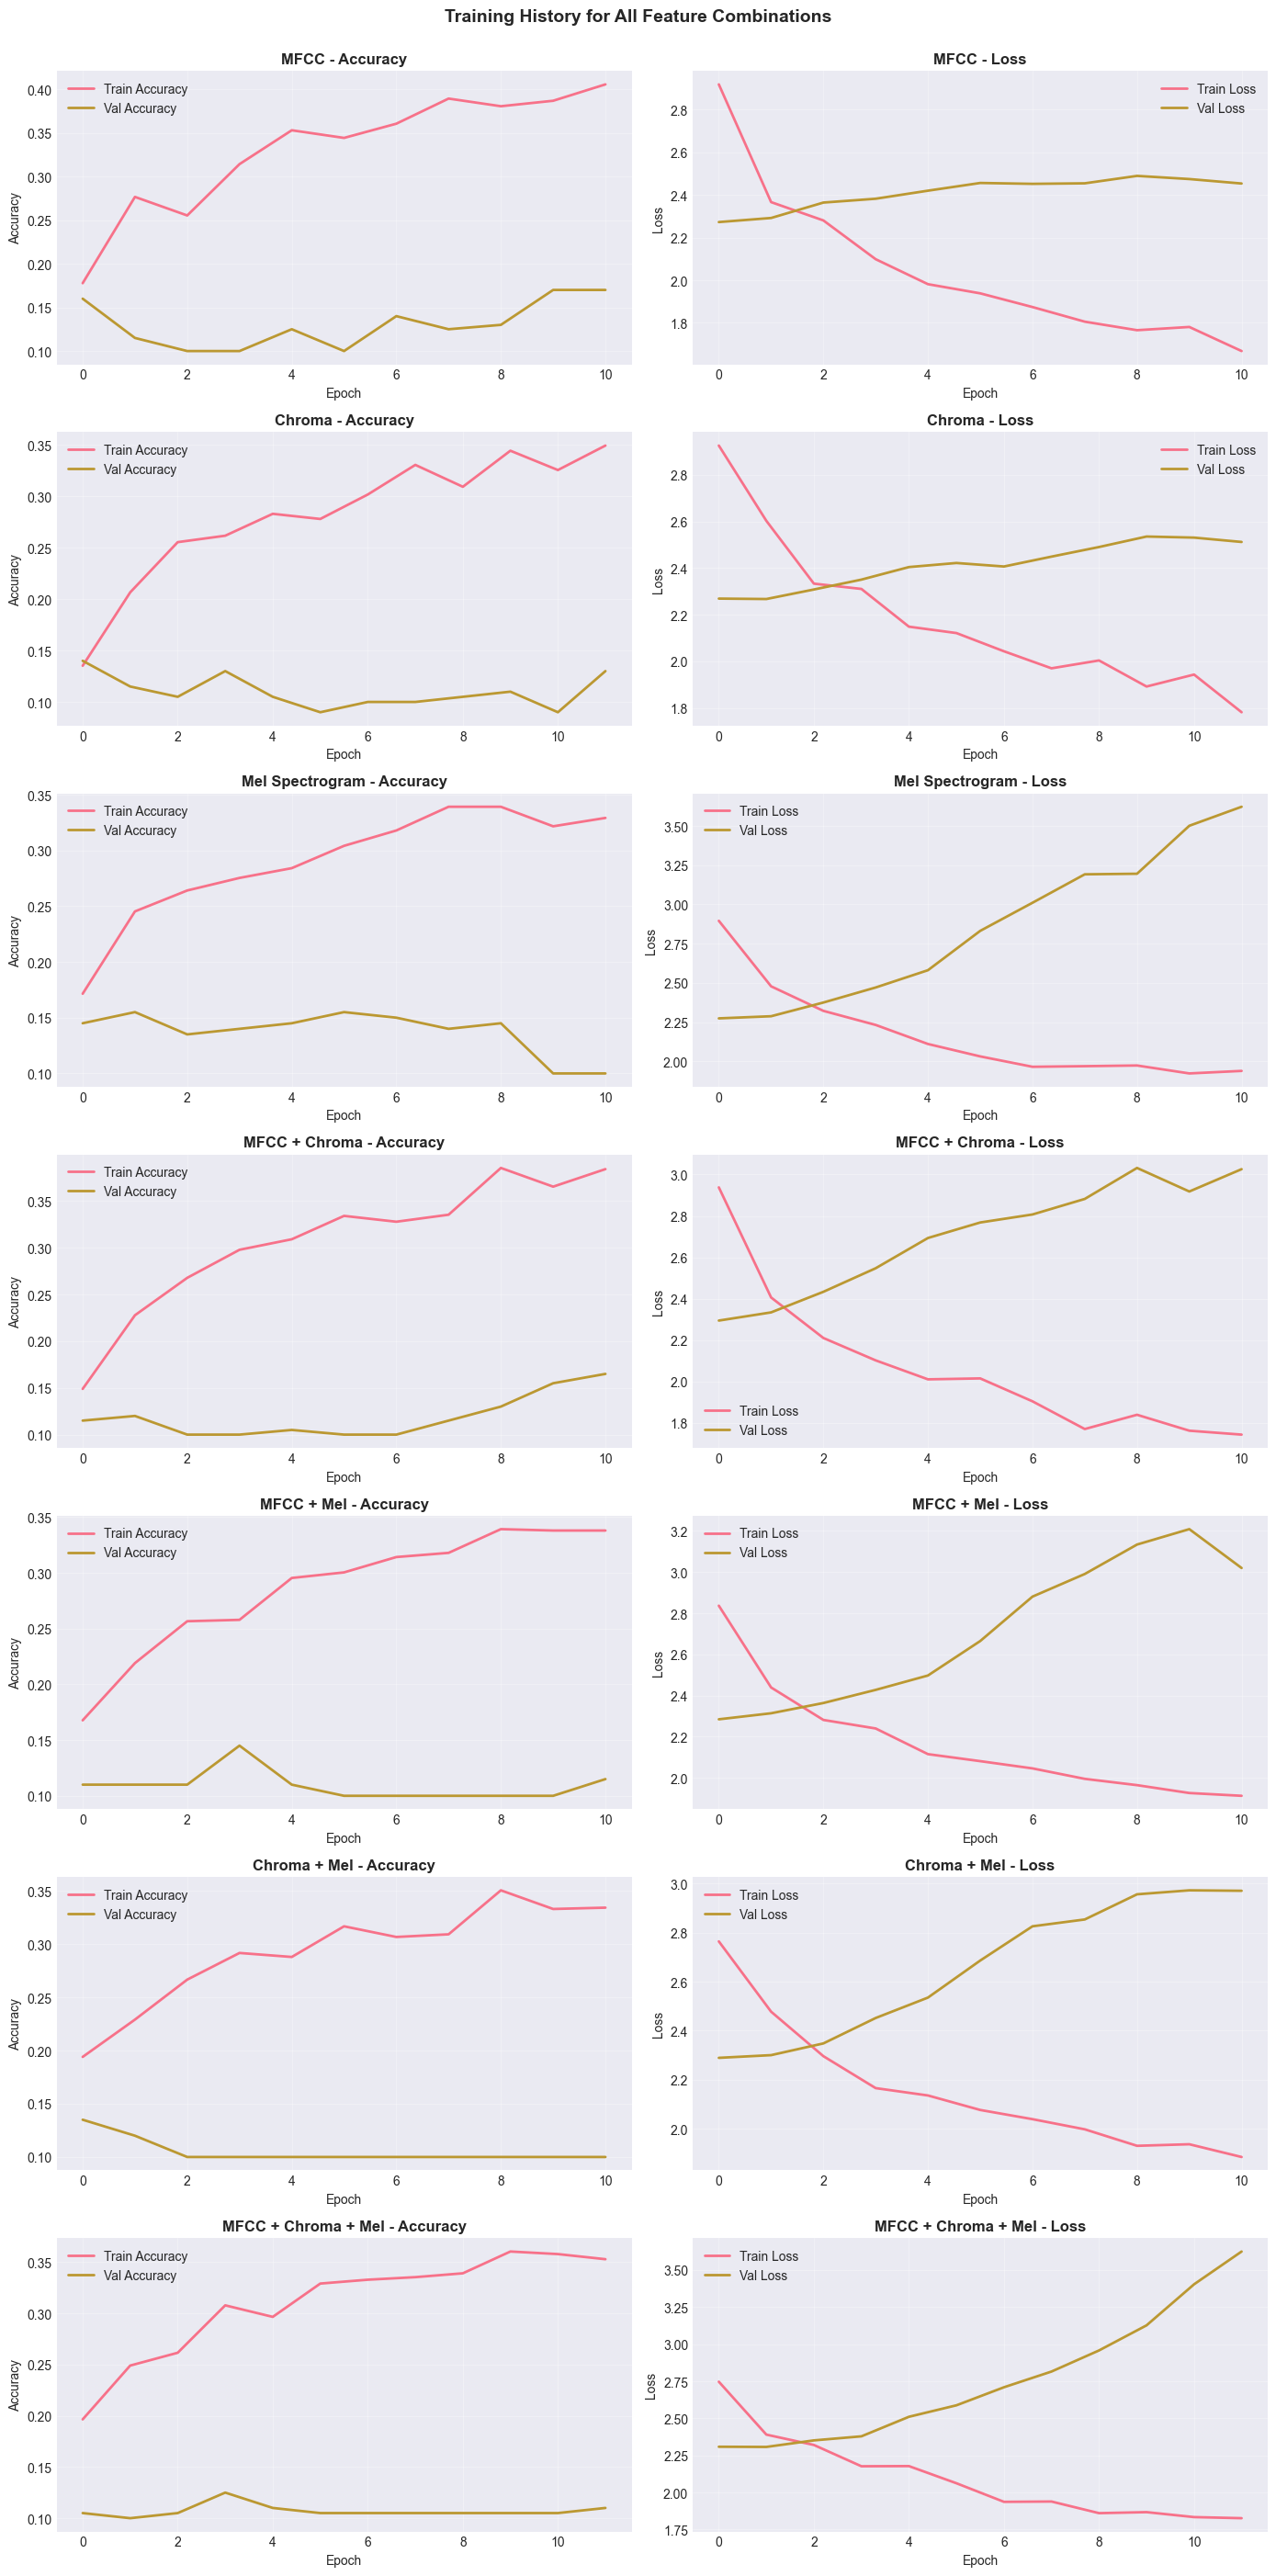

✓ Gambar 1: Training History


In [7]:
# Plot training history untuk semua models
fig, axes = plt.subplots(len(results['history']), 2, figsize=(14, 4*len(results['history'])))

if len(results['history']) == 1:
    axes = axes.reshape(1, -1)

for idx, (combo_name, history) in enumerate(zip(results['feature_combination'], results['history'])):
    # Plot accuracy
    ax = axes[idx, 0]
    ax.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax.set_title(f'{combo_name} - Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot loss
    ax = axes[idx, 1]
    ax.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_title(f'{combo_name} - Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History for All Feature Combinations', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('01_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 1: Training History")

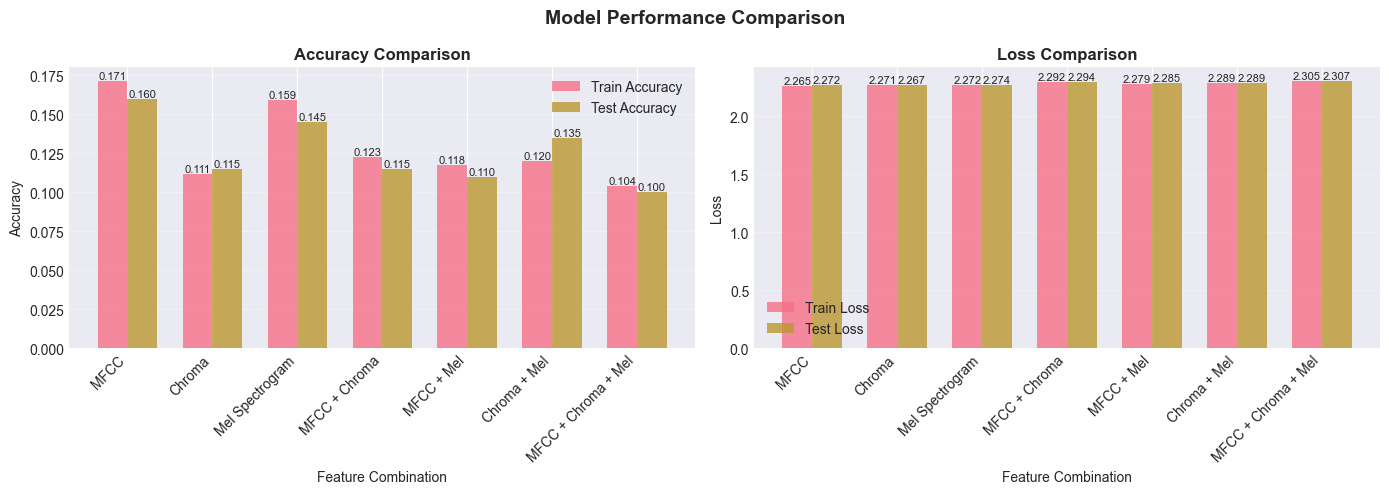

✓ Gambar 2: Model Performance Comparison


In [8]:
# 1. Model Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(results['feature_combination']))
width = 0.35

# Accuracy comparison
ax = axes[0]
bars1 = ax.bar(x_pos - width/2, results['train_accuracy'], width, label='Train Accuracy', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, results['test_accuracy'], width, label='Test Accuracy', alpha=0.8)
ax.set_xlabel('Feature Combination')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(results['feature_combination'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Loss comparison
ax = axes[1]
bars1 = ax.bar(x_pos - width/2, results['train_loss'], width, label='Train Loss', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, results['test_loss'], width, label='Test Loss', alpha=0.8)
ax.set_xlabel('Feature Combination')
ax.set_ylabel('Loss')
ax.set_title('Loss Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(results['feature_combination'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_model_performance_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 2: Model Performance Comparison")

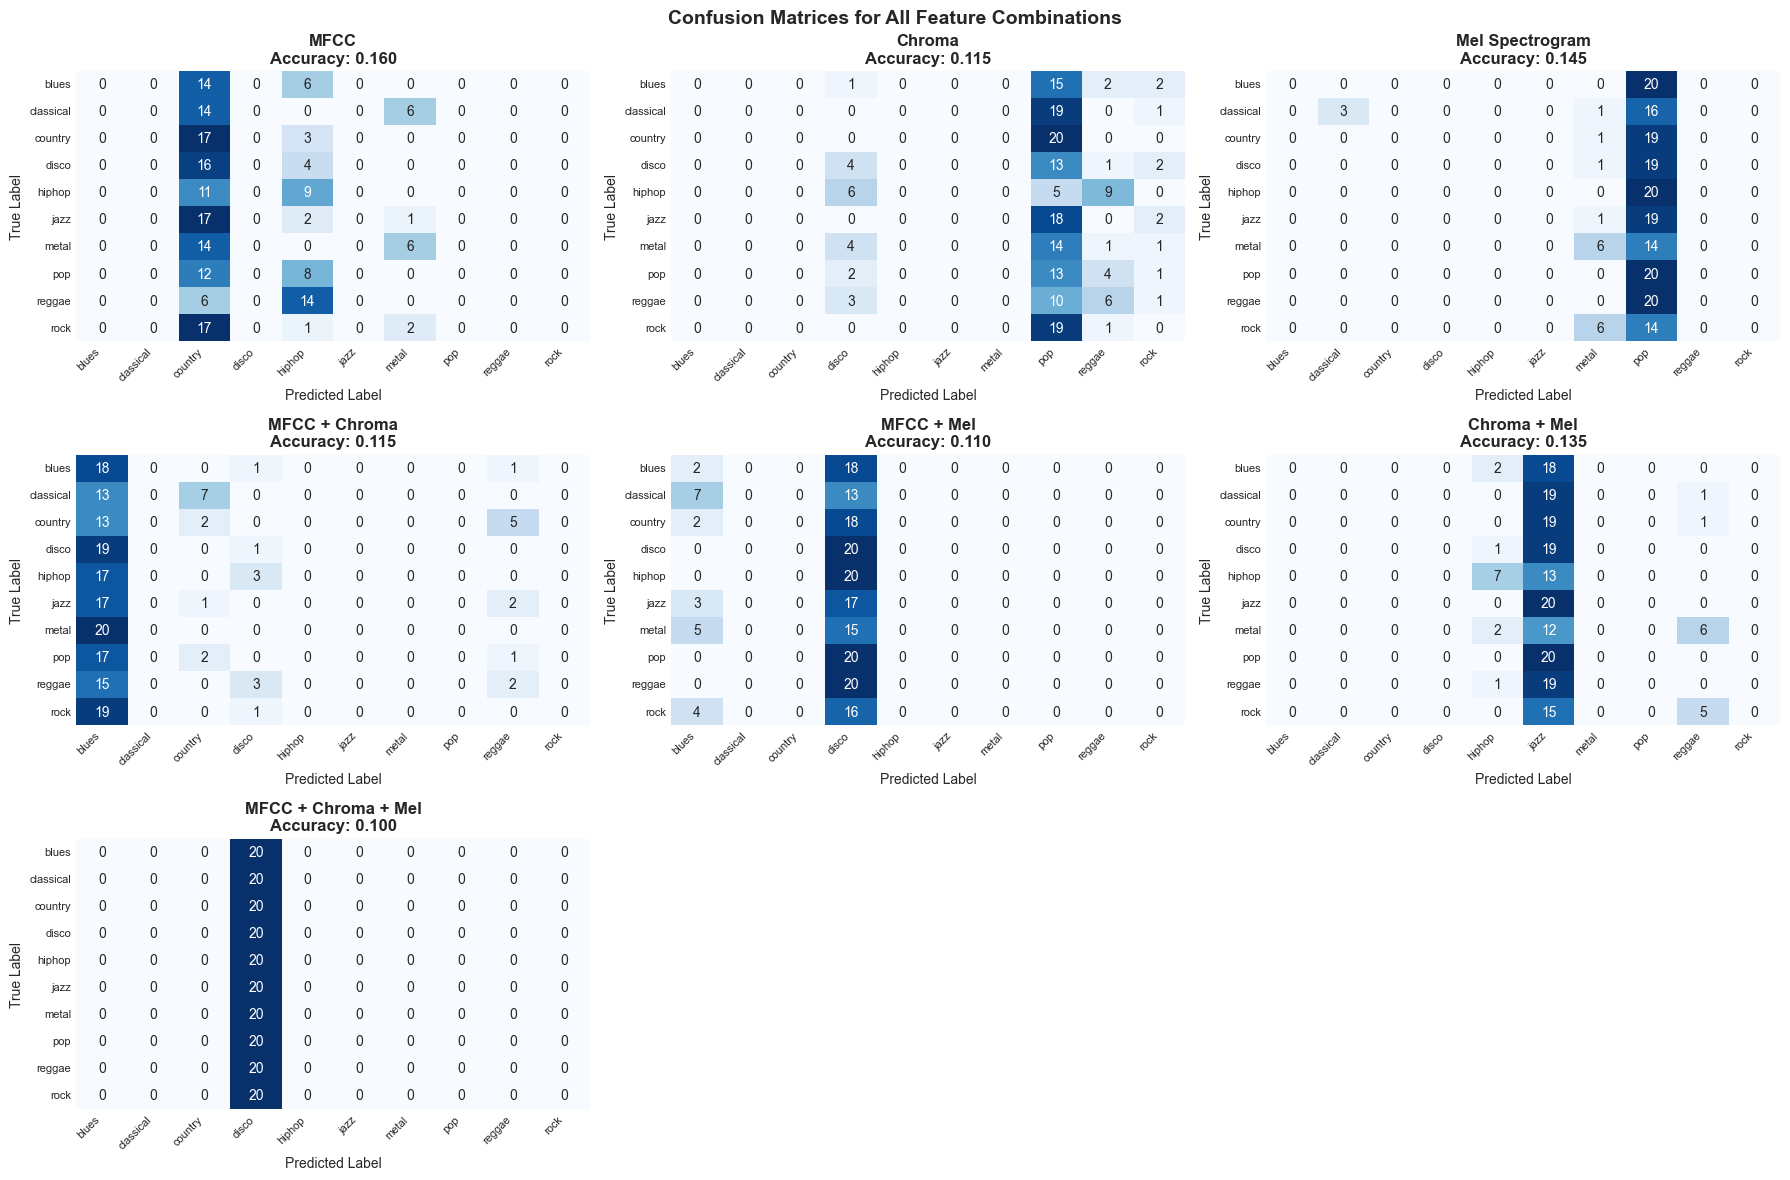

✓ Gambar 3: Confusion Matrices


In [9]:
# 2. Confusion Matrix untuk setiap model
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (combo_name, y_true, y_pred, le) in enumerate(
    zip(results['feature_combination'], results['y_test'], results['y_pred'], results['label_encoder'])):
    
    ax = axes[idx]
    cm = confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{combo_name}\nAccuracy: {accuracy_score(y_true, y_pred):.3f}', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

# Remove extra subplots
for idx in range(len(results['feature_combination']), len(axes)):
    axes[idx].remove()

plt.suptitle('Confusion Matrices for All Feature Combinations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 3: Confusion Matrices")

## 7. Classification Report Detail

In [10]:
# Print classification report untuk setiap model
for combo_name, y_true, y_pred, le in zip(
    results['feature_combination'], results['y_test'], results['y_pred'], results['label_encoder']):
    
    print(f"\n{'='*80}")
    print(f"Classification Report: {combo_name}")
    print(f"{'='*80}")
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")


Classification Report: MFCC
              precision    recall  f1-score   support

       blues     0.0000    0.0000    0.0000        20
   classical     0.0000    0.0000    0.0000        20
     country     0.1232    0.8500    0.2152        20
       disco     0.0000    0.0000    0.0000        20
      hiphop     0.1915    0.4500    0.2687        20
        jazz     0.0000    0.0000    0.0000        20
       metal     0.4000    0.3000    0.3429        20
         pop     0.0000    0.0000    0.0000        20
      reggae     0.0000    0.0000    0.0000        20
        rock     0.0000    0.0000    0.0000        20

    accuracy                         0.1600       200
   macro avg     0.0715    0.1600    0.0827       200
weighted avg     0.0715    0.1600    0.0827       200

Accuracy: 0.1600

Classification Report: Chroma
              precision    recall  f1-score   support

       blues     0.0000    0.0000    0.0000        20
   classical     0.0000    0.0000    0.0000        20
 

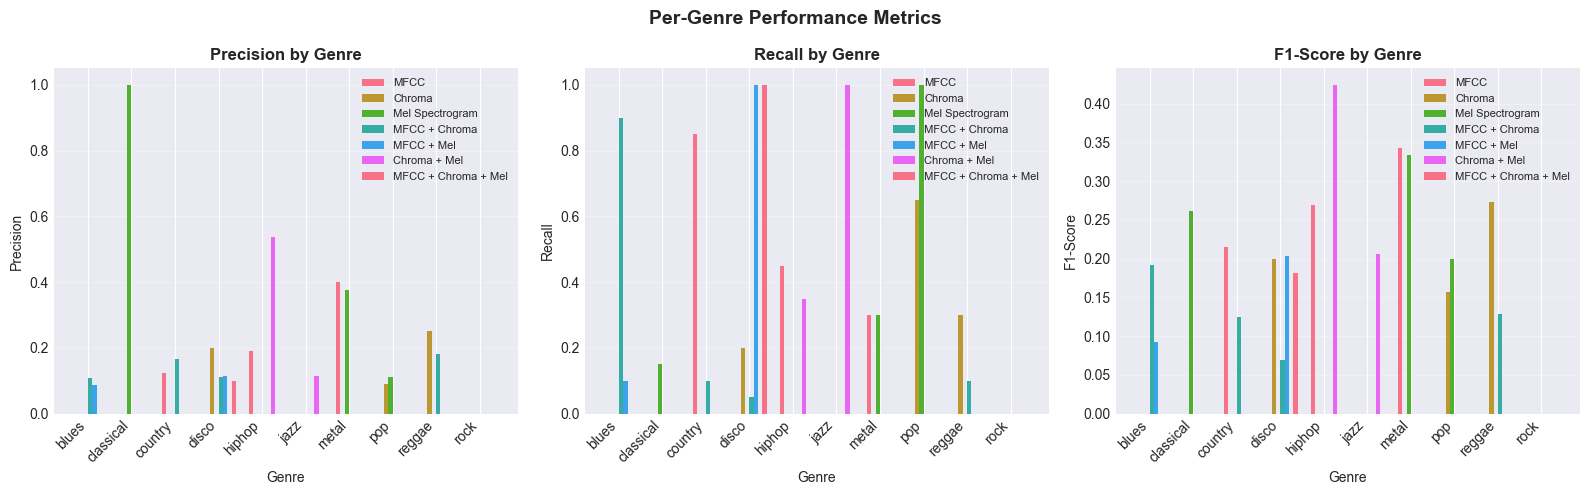

✓ Gambar 4: Per-Genre Metrics


In [11]:
# 3. Per-genre Precision, Recall, F1-Score untuk semua models
genre_metrics = {}

for combo_name, y_true, y_pred, le in zip(
    results['feature_combination'], results['y_test'], results['y_pred'], results['label_encoder']):
    
    report_dict = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    
    genre_metrics[combo_name] = {
        'genres': le.classes_,
        'precision': [report_dict[genre]['precision'] for genre in le.classes_],
        'recall': [report_dict[genre]['recall'] for genre in le.classes_],
        'f1-score': [report_dict[genre]['f1-score'] for genre in le.classes_]
    }

# Plot per-genre metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Get genres
genres = genre_metrics[list(genre_metrics.keys())[0]]['genres']
x_pos = np.arange(len(genres))
width = 0.1

# Precision
ax = axes[0]
for i, combo_name in enumerate(results['feature_combination']):
    ax.bar(x_pos + i*width, genre_metrics[combo_name]['precision'], width, label=combo_name)
ax.set_xlabel('Genre')
ax.set_ylabel('Precision')
ax.set_title('Precision by Genre', fontweight='bold')
ax.set_xticks(x_pos + width * 2.5)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Recall
ax = axes[1]
for i, combo_name in enumerate(results['feature_combination']):
    ax.bar(x_pos + i*width, genre_metrics[combo_name]['recall'], width, label=combo_name)
ax.set_xlabel('Genre')
ax.set_ylabel('Recall')
ax.set_title('Recall by Genre', fontweight='bold')
ax.set_xticks(x_pos + width * 2.5)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# F1-Score
ax = axes[2]
for i, combo_name in enumerate(results['feature_combination']):
    ax.bar(x_pos + i*width, genre_metrics[combo_name]['f1-score'], width, label=combo_name)
ax.set_xlabel('Genre')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score by Genre', fontweight='bold')
ax.set_xticks(x_pos + width * 2.5)
ax.set_xticklabels(genres, rotation=45, ha='right')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Per-Genre Performance Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_per_genre_metrics.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 4: Per-Genre Metrics")

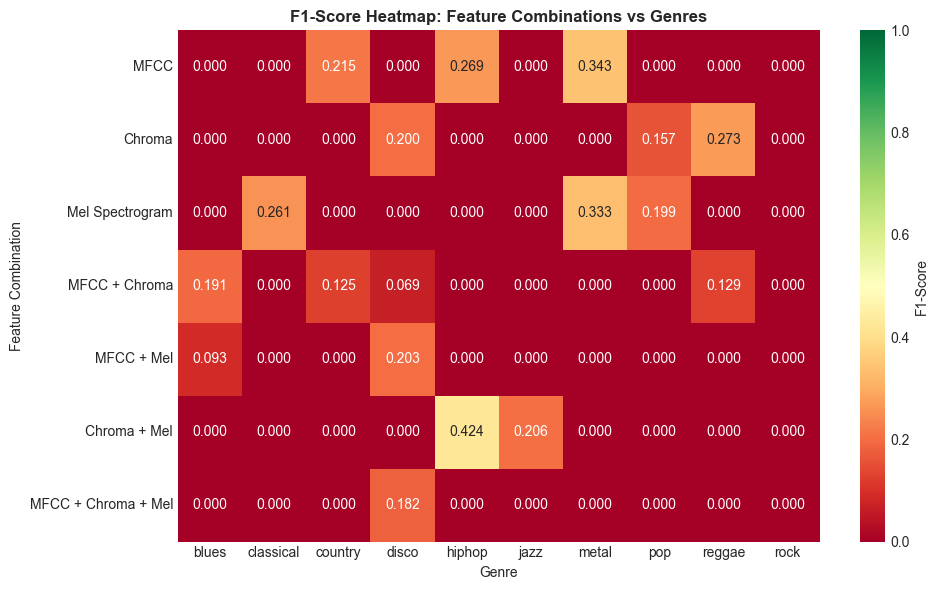

✓ Gambar 5: F1-Score Heatmap


In [12]:
# 4. F1-Score Heatmap untuk semua kombinasi
f1_scores_matrix = []
for combo_name in results['feature_combination']:
    f1_scores_matrix.append(genre_metrics[combo_name]['f1-score'])

f1_scores_matrix = np.array(f1_scores_matrix)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(f1_scores_matrix, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            xticklabels=genres, yticklabels=results['feature_combination'],
            cbar_kws={'label': 'F1-Score'}, vmin=0, vmax=1)
ax.set_title('F1-Score Heatmap: Feature Combinations vs Genres', fontweight='bold', fontsize=12)
ax.set_xlabel('Genre')
ax.set_ylabel('Feature Combination')

plt.tight_layout()
plt.savefig('05_f1_score_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gambar 5: F1-Score Heatmap")

## 8. Summary dan Kesimpulan

In [13]:
print("="*80)
print("RINGKASAN HASIL CNN MUSIC CLASSIFICATION")
print("="*80)

# Ranking by test accuracy
results_sorted = results_df.sort_values('Test Accuracy', ascending=False)
print("\nRanking Model berdasarkan Test Accuracy:")
print(results_sorted.to_string(index=False))

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

best_idx = results_df['Test Accuracy'].idxmax()
worst_idx = results_df['Test Accuracy'].idxmin()

print(f"\n1. BEST PERFORMING MODEL:")
print(f"   - Feature Combination: {results_df.loc[best_idx, 'Feature Combination']}")
print(f"   - Test Accuracy: {results_df.loc[best_idx, 'Test Accuracy']:.4f}")
print(f"   - Test Loss: {results_df.loc[best_idx, 'Test Loss']:.4f}")
print(f"   - Number of Features: {results_df.loc[best_idx, 'Num Features']}")

print(f"\n2. WORST PERFORMING MODEL:")
print(f"   - Feature Combination: {results_df.loc[worst_idx, 'Feature Combination']}")
print(f"   - Test Accuracy: {results_df.loc[worst_idx, 'Test Accuracy']:.4f}")
print(f"   - Test Loss: {results_df.loc[worst_idx, 'Test Loss']:.4f}")

print(f"\n3. AVERAGE TEST ACCURACY:")
print(f"   - Mean: {results_df['Test Accuracy'].mean():.4f}")
print(f"   - Std Dev: {results_df['Test Accuracy'].std():.4f}")

print(f"\n4. FEATURE COMPARISON:")
print(f"   - MFCC only: {results_df.loc[0, 'Test Accuracy']:.4f} ({results_df.loc[0, 'Num Features']} features)")
print(f"   - Chroma only: {results_df.loc[1, 'Test Accuracy']:.4f} ({results_df.loc[1, 'Num Features']} features)")
print(f"   - Mel Spectrogram only: {results_df.loc[2, 'Test Accuracy']:.4f} ({results_df.loc[2, 'Num Features']} features)")

print("\n5. IMPROVEMENT WITH FEATURE COMBINATIONS:")
for idx in range(3, len(results_df)):
    improvement = (results_df.loc[idx, 'Test Accuracy'] - results_df.loc[0, 'Test Accuracy']) / results_df.loc[0, 'Test Accuracy'] * 100
    print(f"   - {results_df.loc[idx, 'Feature Combination']}: {improvement:+.2f}% vs MFCC alone")

print("\n" + "="*80)

RINGKASAN HASIL CNN MUSIC CLASSIFICATION

Ranking Model berdasarkan Test Accuracy:
Feature Combination  Num Features  Train Accuracy  Test Accuracy  Train Loss  Test Loss
               MFCC            26        0.171464          0.160    2.264999   2.272213
    Mel Spectrogram           512        0.158949          0.145    2.272005   2.273755
       Chroma + Mel           584        0.120150          0.135    2.288705   2.288901
             Chroma            72        0.111389          0.115    2.271455   2.267452
      MFCC + Chroma            98        0.122653          0.115    2.292354   2.294394
         MFCC + Mel           538        0.117647          0.110    2.279230   2.284550
MFCC + Chroma + Mel           610        0.103880          0.100    2.304624   2.306966

KEY FINDINGS:

1. BEST PERFORMING MODEL:
   - Feature Combination: MFCC
   - Test Accuracy: 0.1600
   - Test Loss: 2.2722
   - Number of Features: 26

2. WORST PERFORMING MODEL:
   - Feature Combination: MFCC + C

In [14]:
# Best Model Analysis
best_model_idx = results_df['Test Accuracy'].idxmax()
best_combo_name = results['feature_combination'][best_model_idx]
best_y_true = results['y_test'][best_model_idx]
best_y_pred = results['y_pred'][best_model_idx]
best_le = results['label_encoder'][best_model_idx]

print("\n" + "="*80)
print(f"DETAILED ANALYSIS: {best_combo_name} (BEST MODEL)")
print("="*80)

print("\nDetailed Classification Report:")
print(classification_report(best_y_true, best_y_pred, target_names=best_le.classes_, digits=4))

# Per-class accuracy
print("\nPer-Class Accuracy:")
for genre_idx, genre in enumerate(best_le.classes_):
    class_mask = best_y_true == genre_idx
    if class_mask.sum() > 0:
        class_acc = (best_y_pred[class_mask] == best_y_true[class_mask]).mean()
        print(f"  {genre}: {class_acc:.4f}")

print("\n" + "="*80)
print("CONCLUSION")
print("="*80)
print(f"""
Model CNN dengan kombinasi fitur '{best_combo_name}' memberikan performa terbaik
dengan akurasi test sebesar {results_df.loc[best_model_idx, 'Test Accuracy']:.4f}.

Kombinasi fitur terbukti meningkatkan performa dibanding fitur individual.
Penggunaan multiple feature representations dari audio dapat menangkap karakteristik
musik yang berbeda, sehingga menghasilkan klasifikasi yang lebih akurat.

Rekomendasi:
- Gunakan kombinasi fitur untuk akurasi maksimal
- MFCC menangkap karakteristik timbral
- Chroma menangkap pitch-class distribution
- Mel Spectrogram menangkap frequency content
- Kombinasi ketiga memberikan konteks paling lengkap
""")
print("="*80)


DETAILED ANALYSIS: MFCC (BEST MODEL)

Detailed Classification Report:
              precision    recall  f1-score   support

       blues     0.0000    0.0000    0.0000        20
   classical     0.0000    0.0000    0.0000        20
     country     0.1232    0.8500    0.2152        20
       disco     0.0000    0.0000    0.0000        20
      hiphop     0.1915    0.4500    0.2687        20
        jazz     0.0000    0.0000    0.0000        20
       metal     0.4000    0.3000    0.3429        20
         pop     0.0000    0.0000    0.0000        20
      reggae     0.0000    0.0000    0.0000        20
        rock     0.0000    0.0000    0.0000        20

    accuracy                         0.1600       200
   macro avg     0.0715    0.1600    0.0827       200
weighted avg     0.0715    0.1600    0.0827       200


Per-Class Accuracy:
  blues: 0.0000
  classical: 0.0000
  country: 0.8500
  disco: 0.0000
  hiphop: 0.4500
  jazz: 0.0000
  metal: 0.3000
  pop: 0.0000
  reggae: 0.0000


In [15]:
# Save best model
print("\nSaving best model...")
best_model = results['model'][best_model_idx]
best_model.save(f'best_model_{best_combo_name.replace(" ", "_")}.keras')
print(f"✓ Model saved: best_model_{best_combo_name.replace(' ', '_')}.keras")

# Save results to CSV
results_summary_df = pd.DataFrame({
    'Feature Combination': results['feature_combination'],
    'Num Features': results['num_features'],
    'Train Accuracy': results['train_accuracy'],
    'Test Accuracy': results['test_accuracy'],
    'Train Loss': results['train_loss'],
    'Test Loss': results['test_loss']
})

results_summary_df.to_csv('model_comparison_results.csv', index=False)
print("✓ Results saved: model_comparison_results.csv")

print("\n" + "="*80)
print("FILES SAVED:")
print("="*80)
print("1. best_model_MFCC+Chroma+Mel.keras (or best performing model)")
print("2. model_comparison_results.csv")
print("\n✓ Training dan Evaluation selesai!")
print("="*80)


Saving best model...
✓ Model saved: best_model_MFCC.keras
✓ Results saved: model_comparison_results.csv

FILES SAVED:
1. best_model_MFCC+Chroma+Mel.keras (or best performing model)
2. model_comparison_results.csv

✓ Training dan Evaluation selesai!
